# DataPulse — Day 20: SQL CTE Business Analysis

This notebook introduces Common Table Expressions (CTEs) with the existing DataPulse SQLite database. A CTE is a named, temporary result created with `WITH`; it lets a complex business question be built from small, readable steps.

## Learning goals

- Learn basic `WITH` / CTE syntax.
- Create reusable intermediate business datasets.
- Analyze monthly revenue, customers, products, categories, and regions with CTEs.
- Combine multiple CTEs to compare related metrics.
- See why named steps are easier to maintain than deeply nested queries.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

database_path = Path('../data/datapulse.db')
output_directory = Path('../data/processed')
chart_directory = Path('../reports/charts')
output_directory.mkdir(parents=True, exist_ok=True)
chart_directory.mkdir(parents=True, exist_ok=True)

connection = sqlite3.connect(database_path)

In [2]:
# Confirm the live tables and columns used in this notebook.
schema = pd.read_sql_query("""
SELECT name AS table_name, sql
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
""", connection)
schema

,table_name,sql
0,customer_summary,CREATE TABLE customer_summary(\n customer_id ...
1,product_summary,"CREATE TABLE product_summary(\n product TEXT,..."
2,sales,"CREATE TABLE ""sales"" (\n""order_id"" TEXT,\n ""o..."


## 1. Basic `WITH` syntax

The first CTE, `sales_base`, is a named transaction-level dataset. The final `SELECT` reads from that name just as it would from a table. This is useful when the same cleaned or selected columns are needed by later steps.

In [3]:
sales_base_sample = pd.read_sql_query("""
WITH sales_base AS (
    SELECT order_id, order_date, customer_id, product, category,
           region, quantity, net_sales
    FROM sales
)
SELECT *
FROM sales_base
LIMIT 10;
""", connection)
sales_base_sample

,order_id,order_date,customer_id,product,category,region,quantity,net_sales
0,O00001,2025-01-01 00:00:00,C0017,Headphones,Accessories,North,3,"7,500.00"
1,O00002,2025-01-01 02:36:59.483896,C0056,Monitor,Electronics,East,4,"60,000.00"
2,O00003,2025-01-01 05:13:58.967793,C0182,Laptop,Electronics,North,2,"123,500.00"
3,O00004,2025-01-01 07:50:58.451690,C0144,Laptop,Electronics,East,3,"175,500.00"
4,O00005,2025-01-01 10:27:57.935587,C0319,Laptop,Electronics,West,1,"65,000.00"
5,O00006,2025-01-01 13:04:57.419483,C0358,Keyboard,Accessories,North,2,"3,800.00"
6,O00007,2025-01-01 15:41:56.903380,C0003,Smartphone,Electronics,West,1,"40,000.00"
7,O00008,2025-01-01 18:18:56.387277,C0202,Mouse,Accessories,West,5,"3,800.00"
8,O00009,2025-01-01 20:55:55.871174,C0101,Laptop,Electronics,South,1,"61,750.00"
9,O00010,2025-01-01 23:32:55.355071,C0163,Monitor,Electronics,South,5,"75,000.00"


## 2. Monthly revenue and order analysis

`monthly_sales` calculates the monthly business measures once. `monthly_metrics` then adds average order value from those named measures. The two-step structure avoids repeating aggregation logic.

In [4]:
monthly_cte = pd.read_sql_query("""
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', order_date) AS month,
        COUNT(DISTINCT order_id) AS order_count,
        SUM(quantity) AS units_sold,
        ROUND(SUM(net_sales), 2) AS revenue
    FROM sales
    GROUP BY strftime('%Y-%m', order_date)
),
monthly_metrics AS (
    SELECT
        month,
        order_count,
        units_sold,
        revenue,
        ROUND(revenue / NULLIF(order_count, 0), 2) AS average_order_value
    FROM monthly_sales
)
SELECT *
FROM monthly_metrics
ORDER BY month;
""", connection)
monthly_cte

,month,order_count,units_sold,revenue,average_order_value
0,2025-01,285,892,"15,486,360.00","54,338.11"
1,2025-02,257,776,"15,545,610.00","60,488.75"
2,2025-03,284,877,"15,615,460.00","54,984.01"
3,2025-04,275,831,"13,693,690.00","49,795.24"
4,2025-05,285,875,"17,074,470.00","59,910.42"
5,2025-06,275,828,"14,767,605.00","53,700.38"
6,2025-07,284,818,"15,311,520.00","53,913.80"
7,2025-08,284,840,"16,063,435.00","56,561.39"
8,2025-09,276,797,"15,232,320.00","55,189.57"
9,2025-10,284,847,"16,218,785.00","57,108.40"


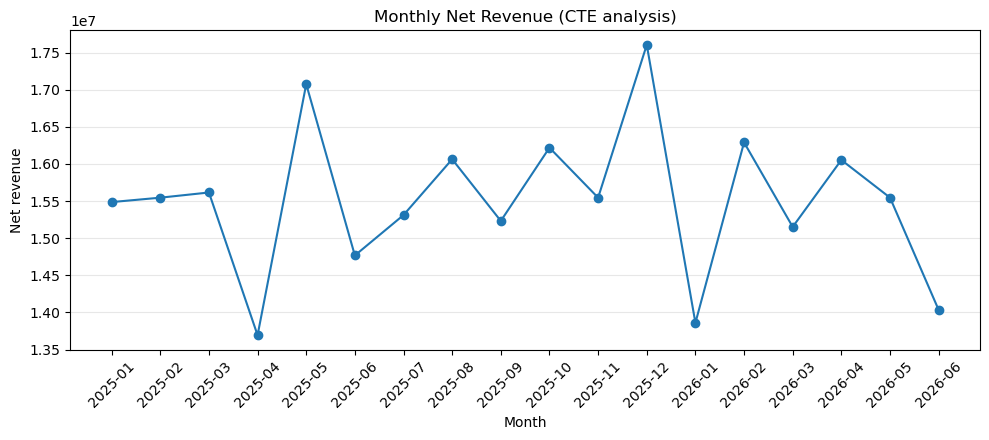

In [5]:
monthly_cte.to_csv(output_directory / 'day20_monthly_cte_metrics.csv', index=False)

fig, axis = plt.subplots(figsize=(10, 4.5))
axis.plot(monthly_cte['month'], monthly_cte['revenue'], marker='o', color='#1f77b4')
axis.set_title('Monthly Net Revenue (CTE analysis)')
axis.set_xlabel('Month')
axis.set_ylabel('Net revenue')
axis.tick_params(axis='x', rotation=45)
axis.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(chart_directory / 'day20_monthly_cte_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Customer-level metrics with reusable CTEs

The first CTE creates one row per customer. A second CTE calculates the average customer revenue. The final query compares each customer against that shared benchmark without deeply nesting a customer aggregation inside every expression.

In [6]:
customer_cte = pd.read_sql_query("""
WITH customer_metrics AS (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS order_count,
        SUM(quantity) AS units_sold,
        ROUND(SUM(net_sales), 2) AS revenue,
        ROUND(AVG(net_sales), 2) AS average_transaction_value
    FROM sales
    GROUP BY customer_id
),
customer_average AS (
    SELECT ROUND(AVG(revenue), 2) AS average_customer_revenue
    FROM customer_metrics
)
SELECT
    cm.customer_id,
    cm.order_count,
    cm.units_sold,
    cm.revenue,
    cm.average_transaction_value,
    ca.average_customer_revenue,
    ROUND(cm.revenue - ca.average_customer_revenue, 2) AS revenue_vs_customer_average
FROM customer_metrics AS cm
CROSS JOIN customer_average AS ca
ORDER BY cm.revenue DESC;
""", connection)
customer_cte.head(10)

,customer_id,order_count,units_sold,revenue,average_transaction_value,average_customer_revenue,revenue_vs_customer_average
0,C0410,15,56,"1,526,130.00","101,742.00","558,188.60","967,941.40"
1,C0127,13,42,"1,523,575.00","117,198.08","558,188.60","965,386.40"
2,C0307,11,36,"1,475,130.00","134,102.73","558,188.60","916,941.40"
3,C0159,22,65,"1,382,975.00","62,862.50","558,188.60","824,786.40"
4,C0215,13,48,"1,382,075.00","106,313.46","558,188.60","823,886.40"
5,C0300,14,41,"1,355,175.00","96,798.21","558,188.60","796,986.40"
6,C0456,20,60,"1,319,975.00","65,998.75","558,188.60","761,786.40"
7,C0050,12,43,"1,281,650.00","106,804.17","558,188.60","723,461.40"
8,C0275,15,52,"1,266,725.00","84,448.33","558,188.60","708,536.40"
9,C0102,14,47,"1,261,750.00","90,125.00","558,188.60","703,561.40"


## 4. Product and category performance

`product_metrics` is the reusable detail layer. `category_metrics` rolls that layer up, then the final query joins them to show each product's revenue share within its actual category.

In [7]:
product_category_cte = pd.read_sql_query("""
WITH product_metrics AS (
    SELECT
        category,
        product,
        COUNT(DISTINCT order_id) AS order_count,
        SUM(quantity) AS units_sold,
        ROUND(SUM(net_sales), 2) AS revenue
    FROM sales
    GROUP BY category, product
),
category_metrics AS (
    SELECT
        category,
        SUM(order_count) AS order_count,
        SUM(units_sold) AS units_sold,
        ROUND(SUM(revenue), 2) AS category_revenue
    FROM product_metrics
    GROUP BY category
)
SELECT
    pm.category,
    pm.product,
    pm.order_count,
    pm.units_sold,
    pm.revenue AS product_revenue,
    cm.category_revenue,
    ROUND(100.0 * pm.revenue / NULLIF(cm.category_revenue, 0), 2) AS category_revenue_share_pct
FROM product_metrics AS pm
INNER JOIN category_metrics AS cm
    ON pm.category = cm.category
ORDER BY product_revenue DESC;
""", connection)
product_category_cte

,category,product,order_count,units_sold,product_revenue,category_revenue,category_revenue_share_pct
0,Electronics,Laptop,639,1917,"115,261,250.00","263,947,000.00",43.67
1,Electronics,Smartphone,649,1944,"71,852,000.00","263,947,000.00",27.22
2,Electronics,Tablet,602,1791,"50,097,000.00","263,947,000.00",18.98
3,Electronics,Monitor,651,1928,"26,736,750.00","263,947,000.00",10.13
4,Accessories,Webcam,616,1894,"6,120,625.00","15,147,300.00",40.41
5,Accessories,Headphones,633,1873,"4,321,375.00","15,147,300.00",28.53
6,Accessories,Keyboard,612,1835,"3,398,100.00","15,147,300.00",22.43
7,Accessories,Mouse,598,1769,"1,307,200.00","15,147,300.00",8.63


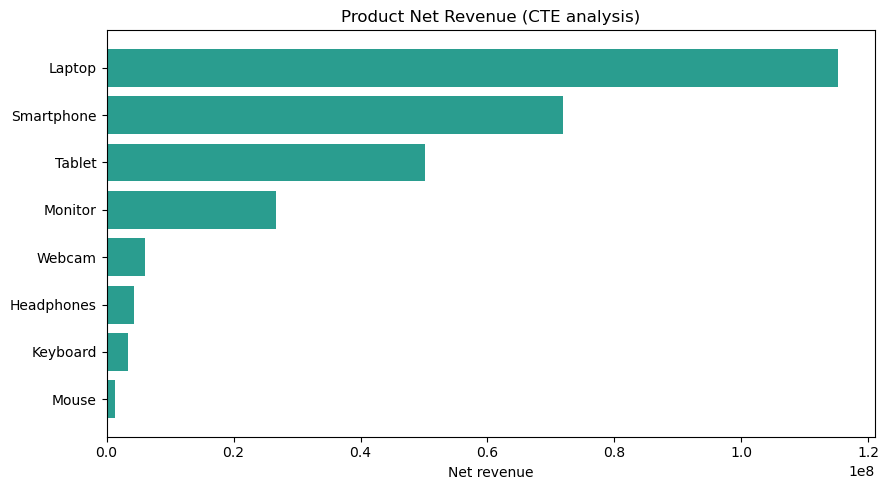

In [8]:
product_category_cte.to_csv(output_directory / 'day20_product_category_cte_metrics.csv', index=False)

plot_data = product_category_cte.sort_values('product_revenue')
fig, axis = plt.subplots(figsize=(9, 5))
axis.barh(plot_data['product'], plot_data['product_revenue'], color='#2a9d8f')
axis.set_title('Product Net Revenue (CTE analysis)')
axis.set_xlabel('Net revenue')
fig.tight_layout()
fig.savefig(chart_directory / 'day20_product_cte_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Combining multiple CTEs for a business question

This analysis asks: how does each region perform within each category? One CTE creates region-category measures, two more create category benchmarks, and the final query compares every row with those benchmarks.

In [9]:
region_category_cte = pd.read_sql_query("""
WITH region_category_metrics AS (
    SELECT
        region,
        category,
        COUNT(DISTINCT order_id) AS order_count,
        ROUND(SUM(net_sales), 2) AS region_category_revenue
    FROM sales
    GROUP BY region, category
),
category_totals AS (
    SELECT category, ROUND(SUM(region_category_revenue), 2) AS category_revenue
    FROM region_category_metrics
    GROUP BY category
),
category_region_average AS (
    SELECT category, ROUND(AVG(region_category_revenue), 2) AS average_region_category_revenue
    FROM region_category_metrics
    GROUP BY category
)
SELECT
    rcm.region,
    rcm.category,
    rcm.order_count,
    rcm.region_category_revenue,
    ct.category_revenue,
    cra.average_region_category_revenue,
    ROUND(rcm.region_category_revenue - cra.average_region_category_revenue, 2)
        AS revenue_vs_category_region_average,
    ROUND(100.0 * rcm.region_category_revenue / NULLIF(ct.category_revenue, 0), 2)
        AS category_revenue_share_pct
FROM region_category_metrics AS rcm
INNER JOIN category_totals AS ct ON rcm.category = ct.category
INNER JOIN category_region_average AS cra ON rcm.category = cra.category
ORDER BY rcm.category, rcm.region_category_revenue DESC;
""", connection)
region_category_cte

,region,category,order_count,region_category_revenue,category_revenue,average_region_category_revenue,revenue_vs_category_region_average,category_revenue_share_pct
0,East,Accessories,635,"3,895,550.00","15,147,300.00","3,786,825.00","108,725.00",25.72
1,West,Accessories,614,"3,844,915.00","15,147,300.00","3,786,825.00","58,090.00",25.38
2,South,Accessories,617,"3,766,690.00","15,147,300.00","3,786,825.00","-20,135.00",24.87
3,North,Accessories,593,"3,640,145.00","15,147,300.00","3,786,825.00","-146,680.00",24.03
4,East,Electronics,630,"68,234,750.00","263,947,000.00","65,986,750.00","2,248,000.00",25.85
5,South,Electronics,657,"66,211,750.00","263,947,000.00","65,986,750.00","225,000.00",25.09
6,West,Electronics,613,"65,525,750.00","263,947,000.00","65,986,750.00","-461,000.00",24.83
7,North,Electronics,641,"63,974,750.00","263,947,000.00","65,986,750.00","-2,012,000.00",24.24


## 6. Comparing calculated customer segments

The segment boundary is not assumed: it is calculated from DataPulse customer revenue in the `customer_average` CTE. The final query compares the resulting segment-level customer count, orders, and revenue.

In [10]:
customer_segment_cte = pd.read_sql_query("""
WITH customer_metrics AS (
    SELECT customer_id, COUNT(DISTINCT order_id) AS order_count,
           ROUND(SUM(net_sales), 2) AS revenue
    FROM sales
    GROUP BY customer_id
),
customer_average AS (
    SELECT AVG(revenue) AS average_customer_revenue
    FROM customer_metrics
),
customer_segments AS (
    SELECT
        cm.customer_id,
        cm.order_count,
        cm.revenue,
        CASE
            WHEN cm.revenue >= ca.average_customer_revenue THEN 'At or above average revenue'
            ELSE 'Below average revenue'
        END AS revenue_segment
    FROM customer_metrics AS cm
    CROSS JOIN customer_average AS ca
)
SELECT
    revenue_segment,
    COUNT(*) AS customer_count,
    ROUND(AVG(order_count), 2) AS average_orders_per_customer,
    ROUND(AVG(revenue), 2) AS average_customer_revenue,
    ROUND(SUM(revenue), 2) AS segment_revenue
FROM customer_segments
GROUP BY revenue_segment
ORDER BY segment_revenue DESC;
""", connection)
customer_segment_cte

,revenue_segment,customer_count,average_orders_per_customer,average_customer_revenue,segment_revenue
0,At or above average revenue,221,11.79,"825,635.81","182,465,515.00"
1,Below average revenue,279,8.58,"346,339.73","96,628,785.00"


In [11]:
region_category_cte.to_csv(output_directory / 'day20_region_category_cte_comparison.csv', index=False)
customer_cte.to_csv(output_directory / 'day20_customer_cte_metrics.csv', index=False)
customer_segment_cte.to_csv(output_directory / 'day20_customer_cte_segments.csv', index=False)

## Why use CTEs instead of deeply nested queries?

CTEs give each analytical step a meaningful name (`customer_metrics`, `category_totals`, and so on). This keeps calculations in one place, makes each intermediate result independently testable, and lets later steps reuse it. The output is the same kind of SQL result as a nested query, but the intent and maintenance path are clearer—especially as business questions gain multiple levels of aggregation.

## Automated insights and business interpretation

The following section is generated from the DataPulse query results in this notebook. It does not use hardcoded business values.

In [12]:
highest_month = monthly_cte.loc[monthly_cte['revenue'].idxmax()]
lowest_month = monthly_cte.loc[monthly_cte['revenue'].idxmin()]
leading_product = product_category_cte.loc[product_category_cte['product_revenue'].idxmax()]
leading_region_category = region_category_cte.loc[region_category_cte['region_category_revenue'].idxmax()]
largest_segment = customer_segment_cte.loc[customer_segment_cte['segment_revenue'].idxmax()]

insights_markdown = f"""## Key findings

- **{highest_month['month']}** had the highest monthly net revenue at **{highest_month['revenue']:,.2f}** across **{int(highest_month['order_count']):,}** orders; **{lowest_month['month']}** was the lowest-revenue month at **{lowest_month['revenue']:,.2f}**.
- **{leading_product['product']}** was the highest-revenue product at **{leading_product['product_revenue']:,.2f}**, contributing **{leading_product['category_revenue_share_pct']:,.2f}%** of **{leading_product['category']}** revenue.
- **{leading_region_category['region']} × {leading_region_category['category']}** was the largest region-category combination, with net revenue of **{leading_region_category['region_category_revenue']:,.2f}** and **{leading_region_category['category_revenue_share_pct']:,.2f}%** of that category's revenue.
- The **{largest_segment['revenue_segment']}** segment generated **{largest_segment['segment_revenue']:,.2f}** across **{int(largest_segment['customer_count']):,}** customers.

## Business interpretation

Revenue differs across months, products, regions, and calculated customer segments. The named CTE layers make those comparisons traceable: transaction data becomes monthly, customer, product, and region-category measures before it is interpreted.

## Limitations

- This analysis uses the available transaction fields only; it does not establish causality for the observed differences.
- Revenue is net sales as stored in the database and is not a profitability measure because no cost fields are available.
- Customer segments are relative to the dataset's calculated average customer revenue, not an externally defined customer-value policy.

## Actionable recommendations

- Review the conditions behind **{highest_month['month']}** performance and test whether successful, available commercial practices can be repeated in lower-revenue months.
- Protect availability and monitor demand for **{leading_product['product']}**, while reviewing whether its category mix can be broadened responsibly.
- Examine the operational and commercial context of **{leading_region_category['region']} × {leading_region_category['category']}** before adapting relevant practices to other region-category combinations.
- Use the calculated customer segment table to prioritize appropriate retention or engagement review for the segment that currently contributes the most revenue.
"""
display(Markdown(insights_markdown))

## Key findings

- **2025-12** had the highest monthly net revenue at **17,603,590.00** across **284** orders; **2025-04** was the lowest-revenue month at **13,693,690.00**.
- **Laptop** was the highest-revenue product at **115,261,250.00**, contributing **43.67%** of **Electronics** revenue.
- **East × Electronics** was the largest region-category combination, with net revenue of **68,234,750.00** and **25.85%** of that category's revenue.
- The **At or above average revenue** segment generated **182,465,515.00** across **221** customers.

## Business interpretation

Revenue differs across months, products, regions, and calculated customer segments. The named CTE layers make those comparisons traceable: transaction data becomes monthly, customer, product, and region-category measures before it is interpreted.

## Limitations

- This analysis uses the available transaction fields only; it does not establish causality for the observed differences.
- Revenue is net sales as stored in the database and is not a profitability measure because no cost fields are available.
- Customer segments are relative to the dataset's calculated average customer revenue, not an externally defined customer-value policy.

## Actionable recommendations

- Review the conditions behind **2025-12** performance and test whether successful, available commercial practices can be repeated in lower-revenue months.
- Protect availability and monitor demand for **Laptop**, while reviewing whether its category mix can be broadened responsibly.
- Examine the operational and commercial context of **East × Electronics** before adapting relevant practices to other region-category combinations.
- Use the calculated customer segment table to prioritize appropriate retention or engagement review for the segment that currently contributes the most revenue.


In [13]:
# A compact validation confirms that each saved output contains results.
validation = pd.DataFrame({
    'dataset': [
        'monthly_cte_metrics', 'customer_cte_metrics', 'product_category_cte_metrics',
        'region_category_cte_comparison', 'customer_cte_segments'
    ],
    'row_count': [
        len(monthly_cte), len(customer_cte), len(product_category_cte),
        len(region_category_cte), len(customer_segment_cte)
    ]
})
validation.to_csv(output_directory / 'day20_cte_output_validation.csv', index=False)
validation

,dataset,row_count
0,monthly_cte_metrics,18
1,customer_cte_metrics,500
2,product_category_cte_metrics,8
3,region_category_cte_comparison,8
4,customer_cte_segments,2


In [14]:
connection.close()
print('Day 20 CTE queries executed successfully and outputs were saved.')

Day 20 CTE queries executed successfully and outputs were saved.
